<a href="https://colab.research.google.com/github/prabuddhayogi/ai-with-python/blob/tweets_sentiment_analysis/tweets_sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from matplotlib import pyplot as plt
import json
import nltk
from sklearn.model_selection import train_test_split
from nltk.corpus import stopwords
data= pd.read_csv("/content/drive/MyDrive/AI-python/lecture28/prochoice_prolife.csv", encoding="latin-1")
data.head()

,Unnamed: 0,author_id,author_name,author_username,created_at,id,public_metrics,text,retweet_count,like_count,target
0,28588,73506221,Oregon Right to Life,OR_RTL,2022-06-23 00:00:06+00:00,1539760170900799490,"{'retweet_count': 5, 'reply_count': 0, 'like_c...",We know that unsupported pregnancies can gener...,5,13,1
1,28587,96631851,Î±Î¹ÑgÏ*Ð¼Î±ÑÎ¹Â¢*ÏÏÑÎ¹Ï,sacraficial,2022-06-23 00:01:14+00:00,1539760456977395712,"{'retweet_count': 0, 'reply_count': 0, 'like_c...",If you are murdered by a George W. Bush weapon...,0,0,1
2,28586,3041829701,skb,skb37027,2022-06-23 00:04:30+00:00,1539761277702213633,"{'retweet_count': 0, 'reply_count': 0, 'like_c...",.@MarshaBlackburn so much for #ProLife. https:...,0,0,1
3,28537,177260708,Right To Life League,Right2LifeLg,2022-06-23 00:09:50+00:00,1539762620055552001,"{'retweet_count': 6, 'reply_count': 3, 'like_c...",Follow our instagram for more posts like this!...,6,19,1
4,27450,1523376591052582912,No Forced Birth,NoForcedBirth,2022-06-23 00:09:57+00:00,1539762647922421763,"{'retweet_count': 0, 'reply_count': 0, 'like_c...",Another classy tweet from the forced birth cro...,0,1,0


In [5]:
print(data.columns)

Index(['Unnamed: 0', 'author_id', 'author_name', 'author_username',
       'created_at', 'id', 'public_metrics', 'text', 'retweet_count',
       'like_count', 'target'],
      dtype='object')


In [6]:
data.isna().sum()

,0
Unnamed: 0,0
author_id,0
author_name,9
author_username,0
created_at,0
id,0
public_metrics,0
text,0
retweet_count,0
like_count,0


In [8]:
data['author_name'] = data['author_name'].fillna("NA")
data.isna().sum()

,0
Unnamed: 0,0
author_id,0
author_name,0
author_username,0
created_at,0
id,0
public_metrics,0
text,0
retweet_count,0
like_count,0


In [9]:
data.describe()

,Unnamed: 0,author_id,id,retweet_count,like_count,target
count,56040.000000,5.604000e+04,5.604000e+04,56040.000000,56040.000000,56040.000000
mean,14015.277320,6.942944e+17,1.541222e+18,1.135046,5.561046,0.510153
std,8098.747894,6.534455e+17,9.109174e+14,16.148907,98.445893,0.499901
min,0.000000,1.135100e+04,1.539760e+18,0.000000,0.000000,0.000000
25%,7004.750000,4.338940e+08,1.540497e+18,0.000000,0.000000,0.000000
50%,14009.500000,8.598755e+17,1.540928e+18,0.000000,0.000000,1.000000
75%,21014.250000,1.337281e+18,1.541610e+18,0.000000,1.000000,1.000000
max,28588.000000,1.543604e+18,1.543746e+18,2009.000000,17377.000000,1.000000


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56040 entries, 0 to 56039
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       56040 non-null  int64 
 1   author_id        56040 non-null  int64 
 2   author_name      56040 non-null  object
 3   author_username  56040 non-null  object
 4   created_at       56040 non-null  object
 5   id               56040 non-null  int64 
 6   public_metrics   56040 non-null  object
 7   text             56040 non-null  object
 8   retweet_count    56040 non-null  int64 
 9   like_count       56040 non-null  int64 
 10  target           56040 non-null  int64 
dtypes: int64(6), object(5)
memory usage: 4.7+ MB


In [27]:
top10_like_count = (
    data.groupby('author_name')['like_count']
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
)

top10_like_count['short_name'] = top10_like_count['author_name'].str[:8]

print(top10_like_count)

                                      author_name  like_count short_name
0                                          Angela       17567     Angela
1                          Pamela Callow, JD, MPA        6253   Pamela C
2                                   Jey Maldonado        5960   Jey Mald
3                               Jennifer Fouquier        5448   Jennifer
4                                   David Draiman        3693   David Dr
5                                           Roger        3041      Roger
6  Ari D Michaels ð³ï¸ââ§ï¸ ð³ï¸âð        3027   Ari D Mi
7                                      Kip Sabian        2910   Kip Sabi
8                                          Zelley        2875     Zelley
9                                Rev. Dean Nelson        2503   Rev. Dea


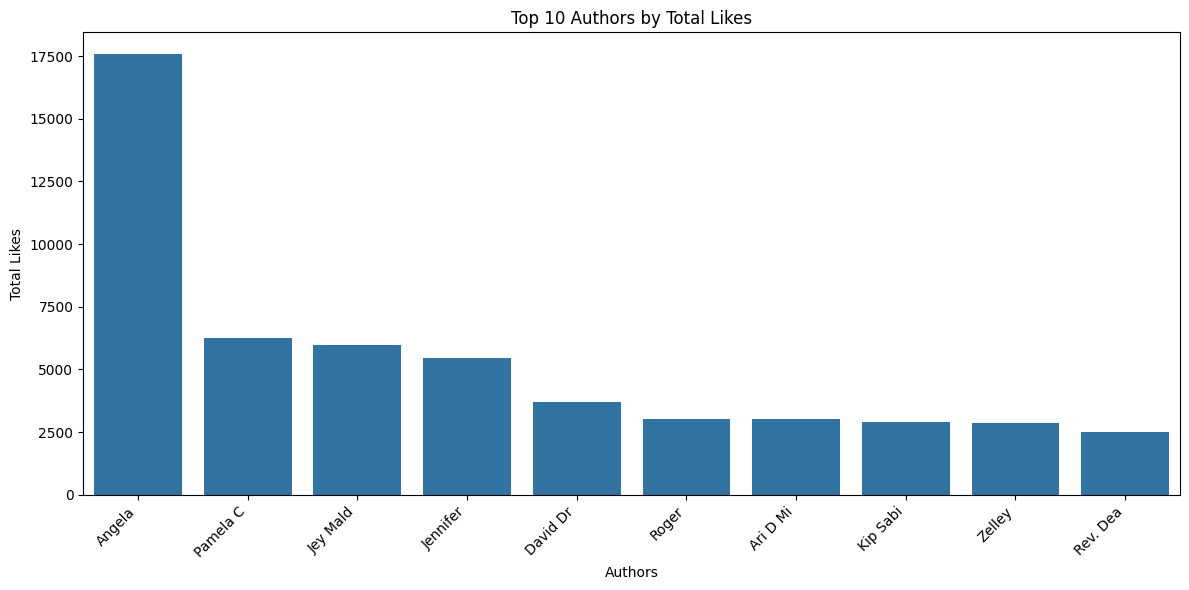

In [29]:
# Bar plot of top 10 users by total likes
plt.figure(figsize=(12, 6))
sns.barplot(x='short_name', y='like_count', data=top10_like_count)
plt.title('Top 10 Authors by Total Likes')
plt.xlabel('Authors')
plt.ylabel('Total Likes')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

In [22]:
top10_retweet_count = (
    data.groupby('author_name')['retweet_count']
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
)
top10_retweet_count['short_name'] = top10_retweet_count['author_name'].str[:8]
print(top10_retweet_count)

              author_name  retweet_count short_name
0                  Angela           2027     Angela
1  Pamela Callow, JD, MPA           1483   Pamela C
2           Jey Maldonado           1383   Jey Mald
3                   Roger            869      Roger
4        Rev. Dean Nelson            821   Rev. Dea
5                  Zelley            748     Zelley
6            suzanne ford            596   suzanne 
7   Bryan Kemper ðºð¸            569   Bryan Ke
8         Cartoonist ZACH            492   Cartooni
9                Juliet R            485   Juliet R


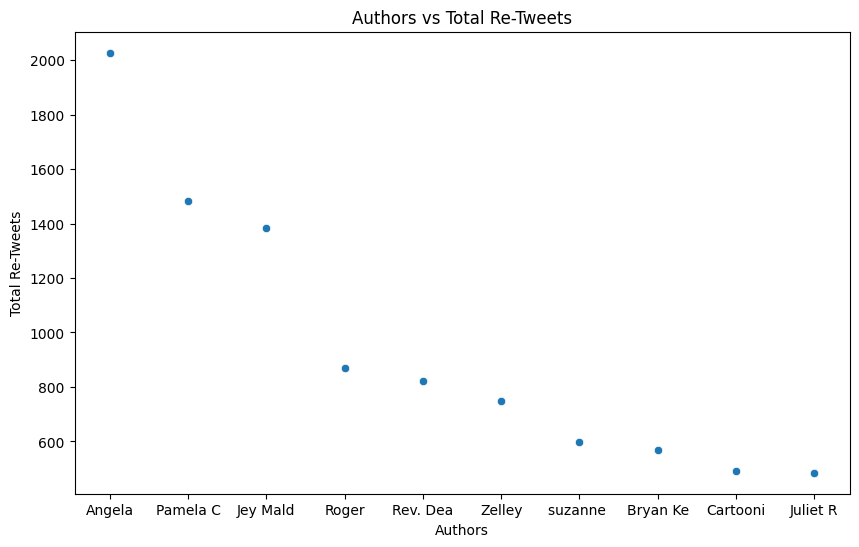

In [25]:
# Scatter plot of authors vs total re-tweets
plt.figure(figsize=(10, 6))
sns.scatterplot(y='retweet_count', x='short_name', data=top10_retweet_count)
plt.title('Authors vs Total Re-Tweets')
plt.xlabel('Authors')
plt.ylabel('Total Re-Tweets')
plt.show()

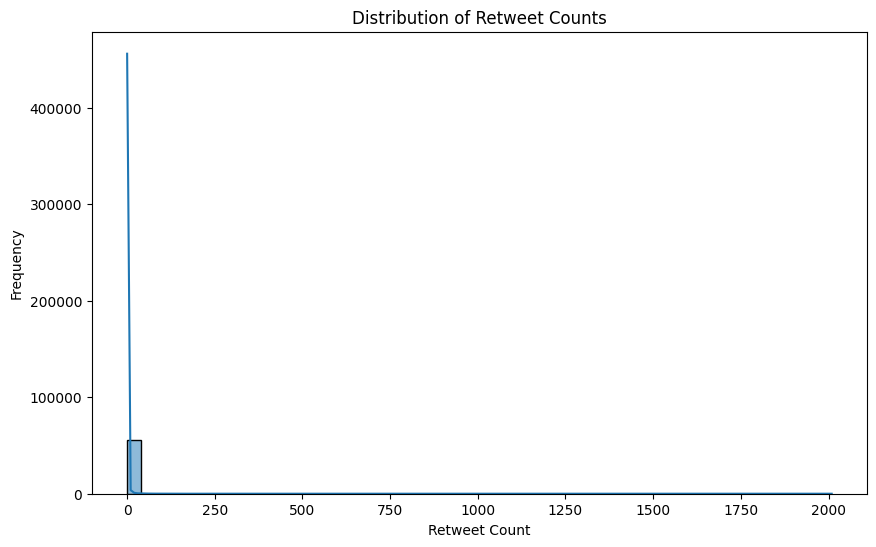

In [30]:
# Create a histogram of the 'retweetcount' column
plt.figure(figsize=(10, 6))
sns.histplot(data['retweet_count'], bins=50, kde=True)
plt.title('Distribution of Retweet Counts')
plt.xlabel('Retweet Count')
plt.ylabel('Frequency')
plt.show()

In [31]:
def emoji(tweet):
    # Smile -- :), : ), :-), (:, ( :, (-:, :') , :O
    tweet = re.sub(r'(:\s?\)|:-\)|\(\s?:|\(-:|:\'\)|:O)', ' positiveemoji ', tweet)
    # Laugh -- :D, : D, :-D, xD, x-D, XD, X-D
    tweet = re.sub(r'(:\s?D|:-D|x-?D|X-?D)', ' positiveemoji ', tweet)
    # Love -- <3, :*
    tweet = re.sub(r'(<3|:\*)', ' positiveemoji ', tweet)
    # Wink -- ;-), ;), ;-D, ;D, (;,  (-; , @-)
    tweet = re.sub(r'(;-?\)|;-?D|\(-?;|@-\))', ' positiveemoji ', tweet)
    # Sad -- :-(, : (, :(, ):, )-:, :-/ , :-|
    tweet = re.sub(r'(:\s?\(|:-\(|\)\s?:|\)-:|:-/|:-\|)', ' negetiveemoji ', tweet)
    # Cry -- :,(, :'(, :"(
    tweet = re.sub(r'(:,\(|:\'\(|:"\()', ' negetiveemoji ', tweet)
    return tweet

In [32]:
with open('/content/drive/MyDrive/AI-python/lecture28/contractions.json', 'r') as f:
    contractions_dict = json.load(f)
contractions = contractions_dict

In [33]:
import re

def process_tweet(tweet):
    tweet = tweet.lower()                                             # Lowercases the string
    tweet = re.sub(r'@[^\s]+','',tweet)                              # Removes usernames
    tweet = re.sub(r'((www\.[^\s]+)|(https?://[^\s]+))',' ',tweet)   # Remove URLs
    tweet = re.sub(r"\d+"," ", str(tweet))                           # Removes all digits
    tweet = re.sub(r'&quot;'," ", tweet)                               # Remove (&quot;)
    tweet = emoji(tweet)                                              # Replaces Emojis
    tweet = re.sub(r"\b[a-zA-Z]\b", "", str(tweet))                   # Removes all single characters
    for word in tweet.split():
        if word.lower() in contractions:
            tweet = tweet.replace(word, contractions[word.lower()])   # Replaces contractions
    tweet = re.sub(r"[^\w\s]", " ", str(tweet))                       # Removes all punctuations
    tweet = re.sub(r'(.)\1+', r'\1\1', tweet)                         # Convert more than 2 letter repetitions to 2 letter
    tweet = re.sub(r"\s+", " ", str(tweet))                           # Replaces double spaces with single space
    return tweet

In [34]:
data['processed_tweet'] = np.vectorize(process_tweet)(data['text'])
data.head()

,Unnamed: 0,author_id,author_name,author_username,created_at,id,public_metrics,text,retweet_count,like_count,target,processed_tweet
0,28588,73506221,Oregon Right to Life,OR_RTL,2022-06-23 00:00:06+00:00,1539760170900799490,"{'retweet_count': 5, 'reply_count': 0, 'like_c...",We know that unsupported pregnancies can gener...,5,13,1,we know that unsupported pregnancies can gener...
1,28587,96631851,Î±Î¹ÑgÏ*Ð¼Î±ÑÎ¹Â¢*ÏÏÑÎ¹Ï,sacraficial,2022-06-23 00:01:14+00:00,1539760456977395712,"{'retweet_count': 0, 'reply_count': 0, 'like_c...",If you are murdered by a George W. Bush weapon...,0,0,1,if you are murdered by george bush weapon of w...
2,28586,3041829701,skb,skb37027,2022-06-23 00:04:30+00:00,1539761277702213633,"{'retweet_count': 0, 'reply_count': 0, 'like_c...",.@MarshaBlackburn so much for #ProLife. https:...,0,0,1,so much for prolife
3,28537,177260708,Right To Life League,Right2LifeLg,2022-06-23 00:09:50+00:00,1539762620055552001,"{'retweet_count': 6, 'reply_count': 3, 'like_c...",Follow our instagram for more posts like this!...,6,19,1,follow our instagram for more posts like this ...
4,27450,1523376591052582912,No Forced Birth,NoForcedBirth,2022-06-23 00:09:57+00:00,1539762647922421763,"{'retweet_count': 0, 'reply_count': 0, 'like_c...",Another classy tweet from the forced birth cro...,0,1,0,another classy tweet from the forced birth cro...


In [35]:
tokenized_tweet = data['processed_tweet'].apply(lambda x: x.split())
tokenized_tweet.head()

,processed_tweet
0,"[we, know, that, unsupported, pregnancies, can..."
1,"[if, you, are, murdered, by, george, bush, wea..."
2,"[so, much, for, prolife]"
3,"[follow, our, instagram, for, more, posts, lik..."
4,"[another, classy, tweet, from, the, forced, bi..."


In [36]:
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [37]:
from nltk.stem.wordnet import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

tokenized_tweet = tokenized_tweet.apply(lambda x: [lemmatizer.lemmatize(i) for i in x])
tokenized_tweet.head()

,processed_tweet
0,"[we, know, that, unsupported, pregnancy, can, ..."
1,"[if, you, are, murdered, by, george, bush, wea..."
2,"[so, much, for, prolife]"
3,"[follow, our, instagram, for, more, post, like..."
4,"[another, classy, tweet, from, the, forced, bi..."


In [38]:
for i in range(len(tokenized_tweet)):


     tokenized_tweet[i] = ' '.join(tokenized_tweet[i])


     #tokenized_tweet[i] = ' '.join([word for word in tokenized_tweet[i] if word not in stopwords])


data['processed_tweet'] = tokenized_tweet
data.head()

,Unnamed: 0,author_id,author_name,author_username,created_at,id,public_metrics,text,retweet_count,like_count,target,processed_tweet
0,28588,73506221,Oregon Right to Life,OR_RTL,2022-06-23 00:00:06+00:00,1539760170900799490,"{'retweet_count': 5, 'reply_count': 0, 'like_c...",We know that unsupported pregnancies can gener...,5,13,1,we know that unsupported pregnancy can generat...
1,28587,96631851,Î±Î¹ÑgÏ*Ð¼Î±ÑÎ¹Â¢*ÏÏÑÎ¹Ï,sacraficial,2022-06-23 00:01:14+00:00,1539760456977395712,"{'retweet_count': 0, 'reply_count': 0, 'like_c...",If you are murdered by a George W. Bush weapon...,0,0,1,if you are murdered by george bush weapon of w...
2,28586,3041829701,skb,skb37027,2022-06-23 00:04:30+00:00,1539761277702213633,"{'retweet_count': 0, 'reply_count': 0, 'like_c...",.@MarshaBlackburn so much for #ProLife. https:...,0,0,1,so much for prolife
3,28537,177260708,Right To Life League,Right2LifeLg,2022-06-23 00:09:50+00:00,1539762620055552001,"{'retweet_count': 6, 'reply_count': 3, 'like_c...",Follow our instagram for more posts like this!...,6,19,1,follow our instagram for more post like this p...
4,27450,1523376591052582912,No Forced Birth,NoForcedBirth,2022-06-23 00:09:57+00:00,1539762647922421763,"{'retweet_count': 0, 'reply_count': 0, 'like_c...",Another classy tweet from the forced birth cro...,0,1,0,another classy tweet from the forced birth cro...


In [39]:
data=data[['text','processed_tweet']]
data

,text,processed_tweet
0,We know that unsupported pregnancies can gener...,we know that unsupported pregnancy can generat...
1,If you are murdered by a George W. Bush weapon...,if you are murdered by george bush weapon of w...
2,.@MarshaBlackburn so much for #ProLife. https:...,so much for prolife
3,Follow our instagram for more posts like this!...,follow our instagram for more post like this p...
4,Another classy tweet from the forced birth cro...,another classy tweet from the forced birth cro...
...,...,...
56035,Next June is going to be more fun #ProLife htt...,next june is going to be more fun prolife
56036,@Hammock_Thomas @MariaLaoise I'm alarmed to he...,alarmed to hear this wa there an arrest made p...
56037,At a #WomensRights and #prochoice rally https:...,at womensrights and prochoice rally
56038,Je refuse leur vaccin expÃ©rimental. \n#monCor...,je refuse leur vaccin expã rimental moncorpsmo...


In [40]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.3 MB/s eta 0:00:00


In [41]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def print_sentiment_scores(sentence):
    snt = analyser.polarity_scores(sentence)

data['neg'] = data['processed_tweet'].apply(lambda x:analyzer.polarity_scores(x)['neg'])
data['neu'] = data['processed_tweet'].apply(lambda x:analyzer.polarity_scores(x)['neu'])
data['pos'] = data['processed_tweet'].apply(lambda x:analyzer.polarity_scores(x)['pos'])
data['compound'] = data['processed_tweet'].apply(lambda x:analyzer.polarity_scores(x)['compound'])
data[['processed_tweet','neg','pos','compound']].head()

,processed_tweet,neg,pos,compound
0,we know that unsupported pregnancy can generat...,0.147,0.292,0.7579
1,if you are murdered by george bush weapon of w...,0.380,0.058,-0.9601
2,so much for prolife,0.000,0.000,0.0000
3,follow our instagram for more post like this p...,0.000,0.258,0.4173
4,another classy tweet from the forced birth cro...,0.101,0.256,0.7606


In [42]:
def getAnalysis(score):
    if score < 0:
      return 'negative'
    elif score == 0:
      return 'neutral'
    else:
      return 'positive'

data['sentiment'] = data['compound'].apply(getAnalysis)
# Show the dataframe
data[['processed_tweet','neg','pos','compound','sentiment']].head()

,processed_tweet,neg,pos,compound,sentiment
0,we know that unsupported pregnancy can generat...,0.147,0.292,0.7579,positive
1,if you are murdered by george bush weapon of w...,0.380,0.058,-0.9601,negative
2,so much for prolife,0.000,0.000,0.0000,neutral
3,follow our instagram for more post like this p...,0.000,0.258,0.4173,positive
4,another classy tweet from the forced birth cro...,0.101,0.256,0.7606,positive


In [43]:
slices = [(data['sentiment'] == 'negative').sum(), (data['sentiment'] == 'positive').sum(), (data['sentiment'] == 'neutral').sum()]
slices

[np.int64(19099), np.int64(20762), np.int64(16179)]

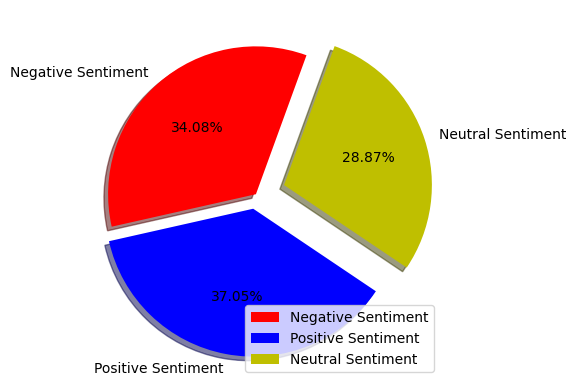

In [44]:
sentiments = ['Negative Sentiment','Positive Sentiment', 'Neutral Sentiment']
slices = [(data['sentiment'] == 'negative').sum(), (data['sentiment'] == 'positive').sum(), (data['sentiment'] == 'neutral').sum()]
colors = ['r','b','y']
plt.pie(slices, labels = sentiments, colors=colors, startangle=70, shadow = True,
        explode = (0, 0.1,0.2), radius = 1, autopct = '%1.2f%%')
plt.legend(loc = "lower right")
plt.show()

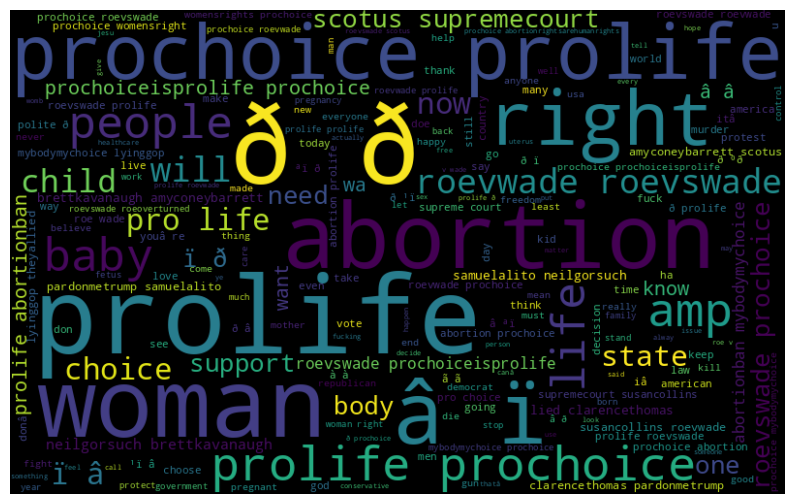

In [45]:
all_words = ' '.join([text for text in data['processed_tweet']])
from wordcloud import WordCloud
wordcloud = WordCloud(width=800, height=500, random_state=21, max_font_size=110).generate(all_words)
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.show()

In [46]:
n_class = 3
n_tweet = 500

if n_class == 2:
    df_pos = data.copy()[data.sentiment == 'positive'][:n_tweet]
    df_neg = data.copy()[data.sentiment == 'negative'][:n_tweet]
    df_neu = pd.DataFrame()
    df = pd.concat([df_pos, df_neg], ignore_index=True).reset_index(drop=True)
elif n_class == 3:
    df_pos = data.copy()[data.sentiment == 'positive'][:n_tweet]
    df_neg = data.copy()[data.sentiment == 'negative'][:n_tweet]
    df_neu = data.copy()[data.sentiment == 'neutral'][:n_tweet]
    df = pd.concat([df_pos, df_neg, df_neu], ignore_index=True).reset_index(drop=True)

In [47]:
X_train, X_test, y_train, y_test = train_test_split(data['processed_tweet'], data['sentiment'], test_size=0.33, random_state=0)

df_train = pd.DataFrame()
df_test = pd.DataFrame()

df_train['processed_tweet'] = X_train
df_train['sentiment'] = y_train
df_train = df_train.reset_index(drop=True)

df_test['processed_tweet'] = X_test
df_test['sentiment'] = y_test
df_test = df_test.reset_index(drop=True)
df_test

,processed_tweet,sentiment
0,and just like that iâ going to make sure my da...,positive
1,all baby are gift from god prolife love live,positive
2,dobbsvjackson roevwade plannedparenthoodvcasey...,neutral
3,my mom never wanted me she grew to love me my ...,negative
4,please retweet until they respond mtv you wann...,positive
...,...,...
18489,brave and terrifying abortion piece by my form...,positive
18490,being polite ð prolife,neutral
18491,being polite ð prolife,neutral
18492,working on more sticker design prochoice crunc...,neutral
